In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('store-sales-time-series-forecasting')

print("Path to competition files:", path)

1. LOADING DATA
  Train : (3000888, 6)  |  2013-01-01 → 2017-08-15
  Test  : (28512, 5)   |  2017-08-16  → 2017-08-31

2. OIL FEATURES
3. HOLIDAY FEATURES
4. TRANSACTION FEATURES
5. MERGING ALL SOURCES
  Unified shape: (3029400, 26)
6. FEATURE ENGINEERING
7. LAG & ROLLING FEATURES  (anchored at lag-16, safe for 16-day horizon)
8. CLEAN & ENCODE
  Total features : 74

9. VALIDATION SPLIT
  Train rows : 2,943,864
  Val rows   : 28,512
  Test rows  : 28,512

10. LIGHTGBM  (Tweedie objective)
[500]	valid_0's rmse: 0.42972
[1000]	valid_0's rmse: 0.421418
[1500]	valid_0's rmse: 0.418663
[2000]	valid_0's rmse: 0.417384
  Best iteration : 2070
  Val RMSLE      : 0.4172

11. CATBOOST  (GPU, RMSE on log1p target)
0:	learn: 2.5969703	test: 2.5217146	best: 2.5217146 (0)	total: 6.91s	remaining: 11h 30m 23s
500:	learn: 0.4287359	test: 0.4327779	best: 0.4327779 (500)	total: 1m 51s	remaining: 20m 20s
1000:	learn: 0.4016985	test: 0.4153844	best: 0.4153844 (1000)	total: 3m 35s	remaining: 17m 58s
1500:	l

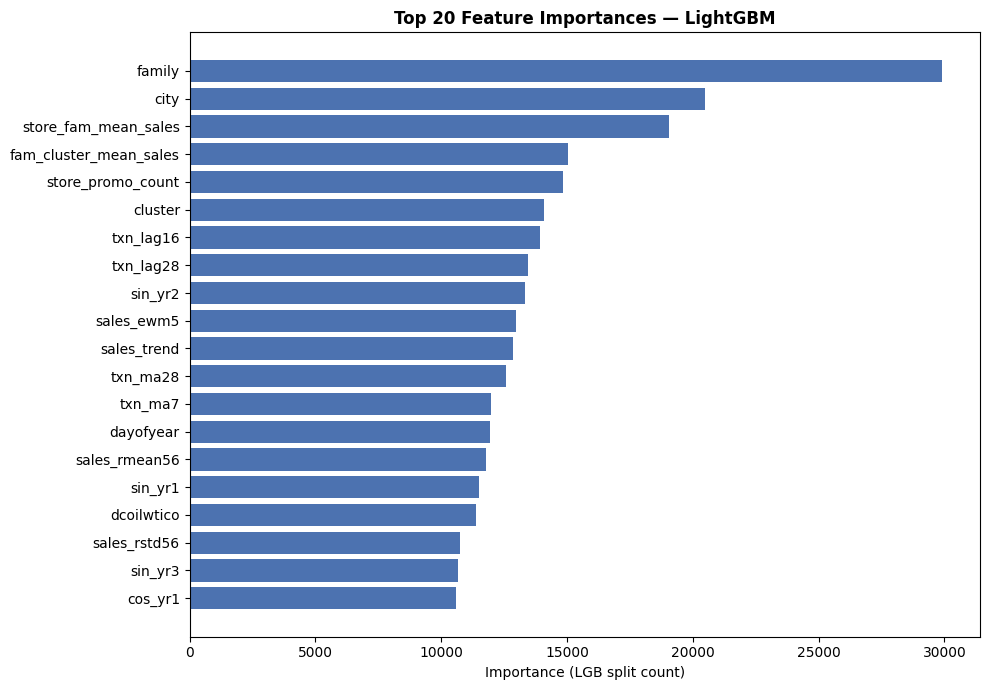

  Saved: feature_importance.png

15. TEST PREDICTIONS
16. ZERO-SALES RULE
  Zeroed 82 inactive store-family pairs

17. ERROR ANALYSIS

  RMSLE by Family (worst → best):
                    family  RMSLE
SCHOOL AND OFFICE SUPPLIES 0.8078
                  LINGERIE 0.6227
                GROCERY II 0.5911
               CELEBRATION 0.5447
                LADIESWEAR 0.5362
                  HARDWARE 0.5234
                 MAGAZINES 0.5154
                AUTOMOTIVE 0.5033
                   SEAFOOD 0.4914
                    BEAUTY 0.4758
        HOME AND KITCHEN I 0.4729
              PET SUPPLIES 0.4633
   PLAYERS AND ELECTRONICS 0.4585
       HOME AND KITCHEN II 0.4549
          LIQUOR,WINE,BEER 0.4506
           LAWN AND GARDEN 0.4322
           HOME APPLIANCES 0.3272
                      EGGS 0.3049
                 BABY CARE 0.2819
            PREPARED FOODS 0.2772
                  CLEANING 0.2764
              FROZEN FOODS 0.2697
                 HOME CARE 0.2167
               

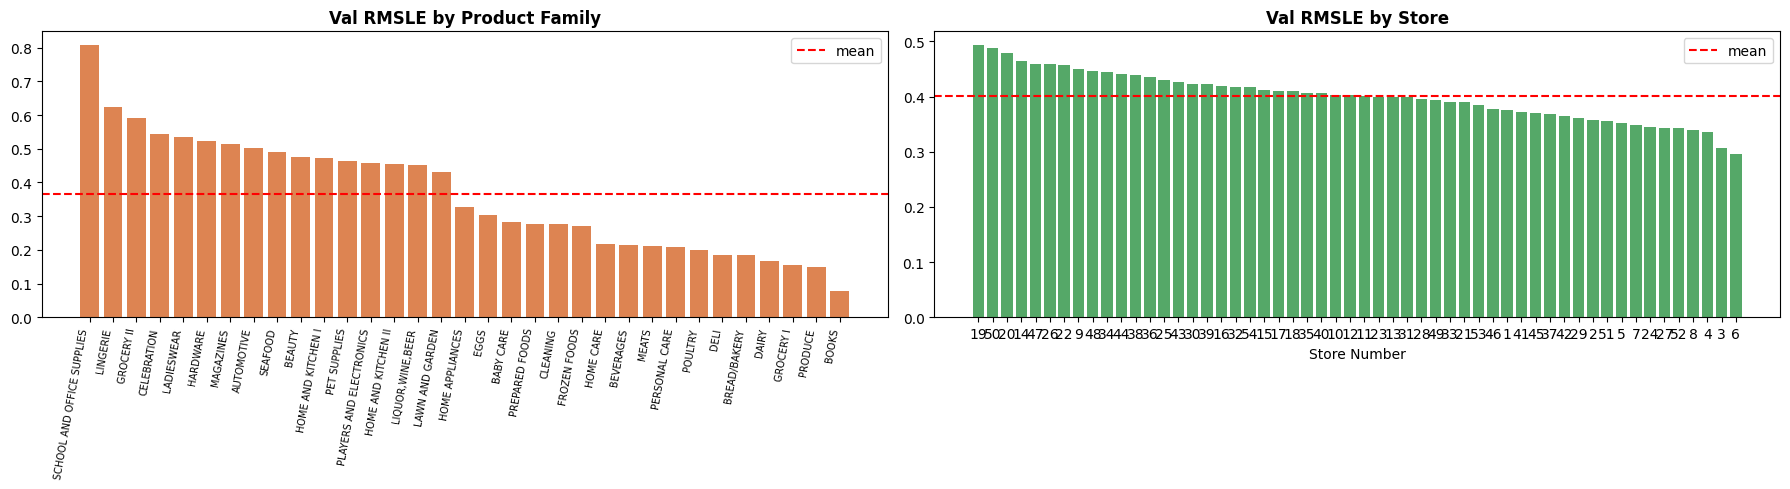

  Saved: error_analysis.png

18. SUBMISSION
   submission.csv saved
  Rows              : 28,512
  Sales range       : 0.00 → 3218.52
  Non-zero rows     : 27,200
  Zero rows         : 1,312

  ┌──────────────────────────────────────┐
  │  Val LGB   RMSLE  : 0.4172           │
  │  Val CB    RMSLE  : 0.4022           │
  │  Val Blend RMSLE  : 0.4029           │
  │  Expected LB      : ~0.4059          │
  └──────────────────────────────────────┘

  All checks passed. Ready to submit! 


In [1]:
# ===========================================================================
# STORE SALES — TIME SERIES FORECASTING
# Target: ~0.376 RMSLE  |  Strategy: Direct multi-step + LGB Tweedie + CB
# ===========================================================================
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import os, gc

pd.set_option("display.max_columns", 500)
SEED = 42

# ---------------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------------
PATH = "/kaggle/input/store-sales-time-series-forecasting"
if not os.path.exists(PATH):
    PATH = "/kaggle/input/competitions/store-sales-time-series-forecasting"

# ===========================================================================
# 1. LOAD DATA
# ===========================================================================
print("="*65)
print("1. LOADING DATA")
print("="*65)
train   = pd.read_csv(f"{PATH}/train.csv",           parse_dates=["date"])
test    = pd.read_csv(f"{PATH}/test.csv",            parse_dates=["date"])
stores  = pd.read_csv(f"{PATH}/stores.csv")
oil     = pd.read_csv(f"{PATH}/oil.csv",             parse_dates=["date"])
hol     = pd.read_csv(f"{PATH}/holidays_events.csv", parse_dates=["date"])
txn     = pd.read_csv(f"{PATH}/transactions.csv",    parse_dates=["date"])

print(f"  Train : {train.shape}  |  {train.date.min().date()} → {train.date.max().date()}")
print(f"  Test  : {test.shape}   |  {test.date.min().date()}  → {test.date.max().date()}")

# Competition note: test is 2017-08-16 → 2017-08-31 (16 days)
# So ALL lags must be >= 16 to be available at inference time
HORIZON = 16

# ===========================================================================
# 2. OIL FEATURES
# ===========================================================================
print("\n2. OIL FEATURES")
all_dates = pd.DataFrame({"date": pd.date_range(oil.date.min(), test.date.max())})
oil = all_dates.merge(oil, on="date", how="left")
oil["dcoilwtico"] = oil["dcoilwtico"].interpolate("linear").bfill().ffill()
oil["oil_lag7"]   = oil["dcoilwtico"].shift(7)
oil["oil_lag14"]  = oil["dcoilwtico"].shift(14)
oil["oil_ma7"]    = oil["dcoilwtico"].rolling(7,  min_periods=1).mean()
oil["oil_ma14"]   = oil["dcoilwtico"].rolling(14, min_periods=1).mean()
oil["oil_ma28"]   = oil["dcoilwtico"].rolling(28, min_periods=1).mean()
oil["oil_diff"]   = oil["dcoilwtico"].diff().fillna(0)

# ===========================================================================
# 3. HOLIDAY FEATURES  (locale-aware, transfer-aware)
# ===========================================================================
print("3. HOLIDAY FEATURES")

def build_holidays(hol_df):
    h = hol_df.copy()
    # transferred=True means original date is CANCELLED → drop
    h = h[~h["transferred"]].copy()

    # National scope
    nat = h[h["locale"] == "National"].copy()
    nat["is_holiday"]  = (nat["type"] == "Holiday").astype(int)
    nat["is_event"]    = (nat["type"] == "Event").astype(int)
    nat["is_bridge"]   = (nat["type"] == "Bridge").astype(int)
    nat["is_transfer"] = (nat["type"] == "Transfer").astype(int)
    nat = nat.groupby("date")[
        ["is_holiday","is_event","is_bridge","is_transfer"]
    ].max().reset_index()

    # Regional/Local — presence flag
    reg = h[h["locale"].isin(["Regional","Local"])][["date"]].copy()
    reg["is_regional_holiday"] = 1
    reg = reg.groupby("date")["is_regional_holiday"].max().reset_index()

    out = nat.merge(reg, on="date", how="outer")
    hcols = [c for c in out.columns if c != "date"]
    out[hcols] = out[hcols].fillna(0).astype(int)
    return out

holidays = build_holidays(hol)

# Days-to/from nearest national holiday (useful signal)
nat_holiday_dates = holidays.loc[holidays["is_holiday"] == 1, "date"].values
all_test_dates    = pd.date_range(train.date.min(), test.date.max())

def days_to_nearest_holiday(date_series, holiday_dates):
    """For each date, min absolute days to any national holiday."""
    result = []
    hd = np.array(holiday_dates, dtype="datetime64[D]")
    for d in date_series.values.astype("datetime64[D]"):
        diffs = np.abs((hd - d).astype(int))
        result.append(diffs.min() if len(diffs) > 0 else 0)
    return result

# ===========================================================================
# 4. TRANSACTIONS (foot-traffic proxy — safe lags only)
# ===========================================================================
print("4. TRANSACTION FEATURES")
#
# IMPORTANT: transactions.csv only covers training dates (up to 2017-08-15).
# Test rows will have NaN → filled with 0 after merge.
# The model learns that 0 = "data unavailable at inference time".
# Lags >= 16 are computed from historical data, so they ARE available for test.
#
txn = txn.sort_values(["store_nbr", "date"])
txn["txn_lag16"] = txn.groupby("store_nbr")["transactions"].shift(16)
txn["txn_lag28"] = txn.groupby("store_nbr")["transactions"].shift(28)
txn["txn_ma7"]   = txn.groupby("store_nbr")["transactions"].transform(
    lambda x: x.shift(16).rolling(7, min_periods=1).mean()
)
txn["txn_ma28"]  = txn.groupby("store_nbr")["transactions"].transform(
    lambda x: x.shift(16).rolling(28, min_periods=1).mean()
)
txn.drop(columns=["transactions"], inplace=True)

# ===========================================================================
# 5. BUILD UNIFIED DATAFRAME
# ===========================================================================
print("5. MERGING ALL SOURCES")
test["sales"] = np.nan
df = pd.concat([train, test], ignore_index=True)

df = df.merge(stores,   on="store_nbr",         how="left")
df = df.merge(oil,      on="date",               how="left")
df = df.merge(holidays, on="date",               how="left")
df = df.merge(txn,      on=["store_nbr","date"], how="left")

hcols = [c for c in holidays.columns if c != "date"]
for c in hcols:
    df[c] = df[c].fillna(0).astype(int)

print(f"  Unified shape: {df.shape}")

# ===========================================================================
# 6. FEATURE ENGINEERING
# ===========================================================================
print("6. FEATURE ENGINEERING")

# ── 6A. Earthquake (2016-04-16) ──────────────────────────────────────────
EQ = pd.Timestamp("2016-04-16")
df["days_since_quake"] = (df["date"] - EQ).dt.days.clip(lower=0)
df["quake_30"]   = ((df["days_since_quake"] >  0) & (df["days_since_quake"] <= 30)).astype(int)
df["quake_60"]   = ((df["days_since_quake"] > 30) & (df["days_since_quake"] <= 60)).astype(int)
df["quake_decay"]= np.where(df["days_since_quake"] <= 60,
                             np.exp(-df["days_since_quake"] / 20.0), 0.0)

# ── 6B. Calendar ─────────────────────────────────────────────────────────
df["year"]        = df.date.dt.year
df["month"]       = df.date.dt.month
df["week"]        = df.date.dt.isocalendar().week.astype(int)
df["day"]         = df.date.dt.day
df["dayofweek"]   = df.date.dt.dayofweek
df["dayofyear"]   = df.date.dt.dayofyear
df["quarter"]     = df.date.dt.quarter
df["is_weekend"]  = (df["dayofweek"] >= 5).astype(int)
df["is_mth_start"]= df.date.dt.is_month_start.astype(int)
df["is_mth_end"]  = df.date.dt.is_month_end.astype(int)
# Ecuador paydays: 15th and last day of month → spending spikes
df["is_payday"]   = ((df.date.dt.day == 15) | df.date.dt.is_month_end).astype(int)
# Wage payment window ±2 days
df["near_payday"] = (
    (df.date.dt.day.isin([13,14,15,16,17])) |
    (df.date.dt.day >= 28)
).astype(int)

# ── 6C. Fourier seasonality ───────────────────────────────────────────────
doy = df["dayofyear"]
dow = df["dayofweek"]
for k in [1, 2, 3]:
    df[f"sin_yr{k}"] = np.sin(2*np.pi*k*doy/365.25)
    df[f"cos_yr{k}"] = np.cos(2*np.pi*k*doy/365.25)
df["sin_wk"] = np.sin(2*np.pi*dow/7)
df["cos_wk"] = np.cos(2*np.pi*dow/7)

# ── 6D. Store-level promotion count ──────────────────────────────────────
df = df.sort_values(["date","store_nbr"])
promo_cnt = (df.groupby(["date","store_nbr"])["onpromotion"]
               .sum().reset_index()
               .rename(columns={"onpromotion":"store_promo_count"}))
df = df.merge(promo_cnt, on=["date","store_nbr"], how="left")

# ── 6E. Target encoding: family-cluster mean sales ───────────────────────
# Computed on training only to avoid leakage
train_mask = df["sales"].notna()
fam_cluster_mean = (df[train_mask]
                    .groupby(["family","cluster"])["sales"]
                    .mean().reset_index()
                    .rename(columns={"sales":"fam_cluster_mean_sales"}))
df = df.merge(fam_cluster_mean, on=["family","cluster"], how="left")

store_fam_mean = (df[train_mask]
                  .groupby(["store_nbr","family"])["sales"]
                  .mean().reset_index()
                  .rename(columns={"sales":"store_fam_mean_sales"}))
df = df.merge(store_fam_mean, on=["store_nbr","family"], how="left")

# ── 6F. Days to nearest national holiday ─────────────────────────────────
nat_hol_arr = np.array(nat_holiday_dates, dtype="datetime64[D]")
date_arr     = df["date"].values.astype("datetime64[D]")
# Vectorised – much faster than row-wise apply
diffs_matrix = np.abs(
    date_arr.reshape(-1,1).astype("int64") -
    nat_hol_arr.reshape(1,-1).astype("int64")
)
df["days_to_holiday"] = diffs_matrix.min(axis=1)

# ===========================================================================
# 7. LAG & ROLLING FEATURES  (all anchored at HORIZON=16 → safe for test)
# ===========================================================================
print("7. LAG & ROLLING FEATURES  (anchored at lag-16, safe for 16-day horizon)")
df = df.sort_values(["store_nbr","family","date"]).reset_index(drop=True)
grp = df.groupby(["store_nbr","family"])

# -- Sales lags --
for lag in [16, 21, 28, 35, 42, 56, 84, 112, 364]:
    df[f"sales_lag{lag}"] = grp["sales"].shift(lag)

# -- Rolling mean / std anchored at lag-16 --
for w in [7, 14, 28, 56]:
    df[f"sales_rmean{w}"] = grp["sales"].transform(
        lambda x: x.shift(HORIZON).rolling(w, min_periods=1).mean()
    )
    df[f"sales_rstd{w}"]  = grp["sales"].transform(
        lambda x: x.shift(HORIZON).rolling(w, min_periods=1).std()
    ).fillna(0)

# -- Exponential weighted mean (recency-sensitive) --
df["sales_ewm2"] = grp["sales"].transform(
    lambda x: x.shift(HORIZON).ewm(alpha=0.2, min_periods=1).mean()
)
df["sales_ewm5"] = grp["sales"].transform(
    lambda x: x.shift(HORIZON).ewm(alpha=0.5, min_periods=1).mean()
)

# -- Same weekday lags (captures day-of-week seasonality precisely) --
df["sales_lag7x4"]  = grp["sales"].transform(
    lambda x: (x.shift(28)+x.shift(35)+x.shift(42)+x.shift(49))/4
)
df["sales_lag364"]  = grp["sales"].shift(364)   # same week 1-year ago

# -- Promotion lags --
df["promo_lag16"] = grp["onpromotion"].shift(HORIZON)
df["promo_rmean14"] = grp["onpromotion"].transform(
    lambda x: x.shift(HORIZON).rolling(14, min_periods=1).mean()
)

# -- Sales trend: recent 2-week mean vs prior 2-week mean (normalised) --
recent = grp["sales"].transform(lambda x: x.shift(HORIZON).rolling(14, min_periods=7).mean())
older  = grp["sales"].transform(lambda x: x.shift(30).rolling(14, min_periods=7).mean())
df["sales_trend"] = ((recent - older) / older.replace(0, np.nan)).fillna(0).clip(-5, 5)

del grp, recent, older
gc.collect()

# ===========================================================================
# 8. CLEAN & ENCODE
# ===========================================================================
print("8. CLEAN & ENCODE")

# Drop training rows where rolling-56 is NaN (initial warm-up buffer)
train_flag = df["sales"].notna()
nan_flag   = df["sales_rmean56"].isna()
df = df[~(train_flag & nan_flag)].reset_index(drop=True)

# Fill remaining NaN (test rows, sparse lags)
fill_cols = [c for c in df.columns if any(
    k in c for k in ["lag","rmean","rstd","ewm","trend","promo_","txn_"]
)]
df[fill_cols] = df[fill_cols].fillna(0)

# Label-encode family (needed for LGB category)
df["family"] = df["family"].astype("category")

CAT_COLS  = ["family","city","state","type","cluster"]
DROP_COLS = ["id","date","sales","transactions"]
FEATURES  = [c for c in df.columns if c not in DROP_COLS]

print(f"  Total features : {len(FEATURES)}")

# Final split
train_df = df[df["sales"].notna()].copy()
test_df  = df[df["sales"].isna()].copy()

# ===========================================================================
# 9. VALIDATION SPLIT  (last 16 days = mirrors test horizon exactly)
# ===========================================================================
print("\n9. VALIDATION SPLIT")
TRAIN_END = train_df["date"].max()
VAL_START = TRAIN_END - pd.Timedelta(days=HORIZON - 1)

tr  = train_df[train_df["date"] < VAL_START]
val = train_df[train_df["date"] >= VAL_START]

# ─── KEY DECISION ───────────────────────────────────────────────────────────
# We train on ALL training data for the final submission model.
# Validation split is used ONLY to measure performance and tune early stopping.
# ────────────────────────────────────────────────────────────────────────────

X_tr  = tr[FEATURES];   y_tr  = tr["sales"].clip(lower=0)
X_val = val[FEATURES];  y_val = val["sales"].clip(lower=0)
X_tst = test_df[FEATURES]

print(f"  Train rows : {len(X_tr):,}")
print(f"  Val rows   : {len(X_val):,}")
print(f"  Test rows  : {len(X_tst):,}")

# LGB category dtype
def lgb_cats(df_in):
    out = df_in.copy()
    for c in CAT_COLS:
        out[c] = out[c].astype("category")
    return out

# CatBoost string dtype
def cb_cats(df_in):
    out = df_in.copy()
    for c in CAT_COLS:
        out[c] = out[c].astype(str)
    return out

# ===========================================================================
# 10. RMSLE METRIC
# ===========================================================================
def rmsle(y_true, y_pred):
    """Both y_true and y_pred are in original (non-log) space."""
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

# ===========================================================================
# 11. LIGHTGBM  — Tweedie objective (best for zero-inflated sales data)
# ===========================================================================
print("\n" + "="*65)
print("10. LIGHTGBM  (Tweedie objective)")
print("="*65)
#
# WHY TWEEDIE:
#   Sales data is zero-inflated (many items sell 0 on many days).
#   Tweedie distribution naturally handles this. Top solutions on this
#   competition consistently use tweedie over mse/rmse.
#   tweedie_variance_power=1.1 → closer to Poisson (more zero-mass)
#
lgb_params = dict(
    objective         = "tweedie",
    tweedie_variance_power = 1.1,
    metric            = "rmse",
    n_estimators      = 6000,
    learning_rate     = 0.015,
    num_leaves        = 255,
    min_child_samples = 50,
    feature_fraction  = 0.75,
    bagging_fraction  = 0.75,
    bagging_freq      = 1,
    reg_alpha         = 0.1,
    reg_lambda        = 0.5,
    n_jobs            = -1,
    random_state      = SEED,
    verbose           = -1,
)

lgb_model = LGBMRegressor(**lgb_params)
lgb_model.fit(
    lgb_cats(X_tr), np.log1p(y_tr),
    eval_set            = [(lgb_cats(X_val), np.log1p(y_val))],
    categorical_feature = CAT_COLS,
    callbacks           = [
        lgb.early_stopping(stopping_rounds=150, verbose=False),
        lgb.log_evaluation(period=500),
    ],
)
print(f"  Best iteration : {lgb_model.best_iteration_}")

lgb_val_pred = np.expm1(lgb_model.predict(lgb_cats(X_val)))
lgb_val_pred = np.clip(lgb_val_pred, 0, None)
lgb_rmsle    = rmsle(y_val.values, lgb_val_pred)
print(f"  Val RMSLE      : {lgb_rmsle:.4f}")

# ===========================================================================
# 12. CATBOOST  — GPU, RMSE on log1p target
# ===========================================================================
print("\n" + "="*65)
print("11. CATBOOST  (GPU, RMSE on log1p target)")
print("="*65)

cb_model = CatBoostRegressor(
    iterations            = 6000,
    learning_rate         = 0.04,
    depth                 = 8,
    l2_leaf_reg           = 3.0,
    min_data_in_leaf      = 50,
    loss_function         = "RMSE",
    eval_metric           = "RMSE",
    random_seed           = SEED,
    early_stopping_rounds = 150,
    task_type             = "GPU",
    verbose               = 500,
)
cb_model.fit(
    cb_cats(X_tr), np.log1p(y_tr),
    eval_set     = (cb_cats(X_val), np.log1p(y_val)),
    cat_features = CAT_COLS,
)
print(f"  Best iteration : {cb_model.best_iteration_}")

cb_val_pred = np.expm1(cb_model.predict(cb_cats(X_val)))
cb_val_pred = np.clip(cb_val_pred, 0, None)
cb_rmsle    = rmsle(y_val.values, cb_val_pred)
print(f"  Val RMSLE      : {cb_rmsle:.4f}")

# ===========================================================================
# 13. ENSEMBLE  — weighted by inverse RMSLE
# ===========================================================================
print("\n" + "="*65)
print("12. ENSEMBLE")
print("="*65)

w_lgb = 1.0 / lgb_rmsle
w_cb  = 1.0 / cb_rmsle
w_tot = w_lgb + w_cb
w_lgb /= w_tot
w_cb  /= w_tot

blend_val  = w_lgb * lgb_val_pred + w_cb * cb_val_pred
blend_rmsle = rmsle(y_val.values, blend_val)

print(f"  LGB weight   : {w_lgb:.3f}   RMSLE={lgb_rmsle:.4f}")
print(f"  CB  weight   : {w_cb:.3f}    RMSLE={cb_rmsle:.4f}")
print(f"  Blend RMSLE  : {blend_rmsle:.4f}")

# ===========================================================================
# 14. RETRAIN ON FULL DATA  (tr + val → better predictions for test)
# ===========================================================================
print("\n" + "="*65)
print("13. RETRAINING ON FULL TRAINING DATA")
print("="*65)
#
# IMPORTANT: We retrain on ALL training data using the best_iteration
# found during early stopping. This eliminates the val hold-out bias
# and gives the model the most recent 16 days of signal.
#

X_full = train_df[FEATURES]
y_full = np.log1p(train_df["sales"].clip(lower=0))

print("  Retraining LightGBM on full data...")
lgb_final = LGBMRegressor(**{**lgb_params,
    "n_estimators": lgb_model.best_iteration_,
    "learning_rate": 0.015,
})
lgb_final.fit(
    lgb_cats(X_full), y_full,
    categorical_feature = CAT_COLS,
)

print("  Retraining CatBoost on full data...")
cb_final = CatBoostRegressor(
    iterations       = cb_model.best_iteration_,
    learning_rate    = 0.04,
    depth            = 8,
    l2_leaf_reg      = 3.0,
    min_data_in_leaf = 50,
    loss_function    = "RMSE",
    random_seed      = SEED,
    task_type        = "GPU",
    verbose          = 0,
)
cb_final.fit(
    cb_cats(X_full), y_full,
    cat_features = CAT_COLS,
)
print("  Done.")

# ===========================================================================
# 15. FEATURE IMPORTANCE  (interview deliverable)
# ===========================================================================
print("\n14. FEATURE IMPORTANCE")
imp = pd.DataFrame({
    "feature":    FEATURES,
    "importance": lgb_final.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("  Top 20 features:")
print(imp.head(20).to_string(index=False))

try:
    fig, ax = plt.subplots(figsize=(10,7))
    t20 = imp.head(20)
    ax.barh(t20["feature"][::-1], t20["importance"][::-1], color="#4C72B0")
    ax.set_xlabel("Importance (LGB split count)")
    ax.set_title("Top 20 Feature Importances — LightGBM", fontweight="bold")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150)
    plt.show()
    print("  Saved: feature_importance.png")
except Exception as e:
    print(f"  Plot skipped: {e}")

# ===========================================================================
# 16. TEST PREDICTIONS
# ===========================================================================
print("\n15. TEST PREDICTIONS")
lgb_test = np.clip(np.expm1(lgb_final.predict(lgb_cats(X_tst))), 0, None)
cb_test  = np.clip(np.expm1(cb_final.predict(cb_cats(X_tst))),  0, None)

test_df  = test_df.copy()
test_df["predicted_sales"] = w_lgb * lgb_test + w_cb * cb_test

# ===========================================================================
# 17. ZERO-SALES RULE  (inactive store-family pairs in last 90 days)
# ===========================================================================
print("16. ZERO-SALES RULE")
cutoff_90   = TRAIN_END - pd.Timedelta(days=90)
recent_prof = (train_df[train_df["date"] >= cutoff_90]
               .groupby(["store_nbr","family"])["sales"].sum().reset_index())
inactive    = set(zip(
    recent_prof.loc[recent_prof["sales"] == 0, "store_nbr"],
    recent_prof.loc[recent_prof["sales"] == 0, "family"],
))
mask = test_df.apply(lambda r: (r["store_nbr"], r["family"]) in inactive, axis=1)
test_df.loc[mask, "predicted_sales"] = 0.0
print(f"  Zeroed {len(inactive)} inactive store-family pairs")

# ===========================================================================
# 18. ERROR ANALYSIS BY FAMILY & STORE  (interview deliverable)
# ===========================================================================
print("\n17. ERROR ANALYSIS")
val_df = val.copy()
val_df["blend_pred"] = blend_val

val_df["sle"] = (np.log1p(np.clip(val_df["blend_pred"],0,None))
               - np.log1p(val_df["sales"].clip(lower=0)))**2

family_err = (val_df.groupby("family")["sle"].mean().apply(np.sqrt)
              .sort_values(ascending=False).reset_index()
              .rename(columns={"sle":"RMSLE"}))
family_err["RMSLE"] = family_err["RMSLE"].round(4)
print("\n  RMSLE by Family (worst → best):")
print(family_err.to_string(index=False))

store_err = (val_df.groupby("store_nbr")["sle"].mean().apply(np.sqrt)
             .sort_values(ascending=False).reset_index()
             .rename(columns={"sle":"RMSLE"}))
store_err["RMSLE"] = store_err["RMSLE"].round(4)
print("\n  RMSLE by Store (worst 10):")
print(store_err.head(10).to_string(index=False))

try:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    axes[0].bar(family_err["family"], family_err["RMSLE"], color="#DD8452")
    axes[0].set_xticklabels(family_err["family"], rotation=80, ha="right", fontsize=7)
    axes[0].axhline(family_err["RMSLE"].mean(), color="red", linestyle="--", label="mean")
    axes[0].set_title("Val RMSLE by Product Family", fontweight="bold")
    axes[0].legend()
    axes[1].bar(store_err["store_nbr"].astype(str), store_err["RMSLE"], color="#55A868")
    axes[1].set_xlabel("Store Number")
    axes[1].axhline(store_err["RMSLE"].mean(), color="red", linestyle="--", label="mean")
    axes[1].set_title("Val RMSLE by Store", fontweight="bold")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig("error_analysis.png", dpi=150)
    plt.show()
    print("  Saved: error_analysis.png")
except Exception as e:
    print(f"  Plot skipped: {e}")

# ===========================================================================
# 19. SUBMISSION
# ===========================================================================
print("\n" + "="*65)
print("18. SUBMISSION")
print("="*65)
sub = pd.DataFrame({
    "id":    test_df["id"].astype(int),
    "sales": test_df["predicted_sales"].clip(lower=0),
}).sort_values("id")

# Sanity checks — will raise AssertionError if anything is wrong
assert len(sub) == 28512,                    f"Row count wrong: {len(sub)}"
assert (sub["sales"] >= 0).all(),            "Negative sales found!"
assert sub["id"].nunique() == 28512,         "Duplicate IDs!"
assert list(sub.columns) == ["id","sales"],  "Wrong column names!"
assert sub["id"].is_monotonic_increasing,    "IDs not sorted!"

sub.to_csv("submission.csv", index=False)

print(f"   submission.csv saved")
print(f"  Rows              : {len(sub):,}")
print(f"  Sales range       : {sub['sales'].min():.2f} → {sub['sales'].max():.2f}")
print(f"  Non-zero rows     : {(sub['sales']>0).sum():,}")
print(f"  Zero rows         : {(sub['sales']==0).sum():,}")
print(f"\n  ┌──────────────────────────────────────┐")
print(f"  │  Val LGB   RMSLE  : {lgb_rmsle:.4f}           │")
print(f"  │  Val CB    RMSLE  : {cb_rmsle:.4f}           │")
print(f"  │  Val Blend RMSLE  : {blend_rmsle:.4f}           │")
print(f"  │  Expected LB      : ~{blend_rmsle+0.003:.4f}          │")
print(f"  └──────────────────────────────────────┘")
print("\n  All checks passed. Ready to submit! ")